# Build Asset Graph Database

Migrates the crude-oil asset graph from `asset_graph/asset_graph.json` into a relational schema in local PostgreSQL (`eia_crude.oil_logistics_network`), then renders an ER diagram.

**Layered model**

1. **Asset graph (static)** — `nodes`, `node_geography`, `node_configuration`. Identity, geography labels, class-specific configuration. Doesn't change with scenarios.
2. **Variables (slot definitions)** — `variable_types`, `products`, `variables`. The universal set of mass-balance slots: P, F_in, F_out, C, S, B per node, plus a `phi` slot per directed edge. Slots carry no data and no formula.
3. **Time series (data)** — `time_series` (catalog: variable_type, product, asset_ref, source, ...) and `time_series_data` (timeseries_id, observation_date, saved_date, value). All values in mbd. Step-forward semantics — a value at date `t` holds until the next observation.
4. **Scenarios (assignments)** — `scenarios`, `scenario_node_status` (which nodes are active vs collapsed for that scenario), `variable_assignments` (for each active variable, an assignment to a time series, a formula, or zero, with `effective_from` so the source can change over time). Together (graph structure + assignments) they let the balance equation be evaluated.

**Derived views**

- `edges` — projection of `variables` where `variable_type='phi'`.
- `resolution_hierarchy` — parent → child relationships derived from `variable_assignments.formula_inputs` for `sum_over_children` formulas. The hierarchy is *not* stored as a primary table; per principle 2.4 ("relationships are only given by variables"), it is implied by which variables list which other variables as their formula inputs.

**Schema-level invariants**

- Edges are derived from `phi` variables, never declared independently (principle 2.4).
- Aggregation "edges" from the JSON are not migrated — the parent/child rollup is implicit via `formula_inputs` (issues 5.1, 5.3).
- At most one variable per `(variable_type, product, node_id, ref_node_id)` tuple (principle 2.8) — partial unique indexes.
- A variable assignment is exclusively one of `timeseries`, `formula`, or `zero` — CHECK constraint.
- Bidirectional pipelines are two `phi` slots, one per direction (principle 2.12).

## 0. Init

In [1]:
import json
import os
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.exc import IntegrityError
from IPython.display import display

PG_HOST   = os.environ.get("PG_HOST",   "localhost")
PG_PORT   = os.environ.get("PG_PORT",   "5432")
PG_DB     = os.environ.get("PG_DB",     "eia_crude")
PG_USER   = os.environ.get("PG_USER",   "eia_user")
PG_PASS   = os.environ.get("PG_PASS",   "eia_password")
PG_SCHEMA = os.environ.get("PG_SCHEMA", "oil_logistics_network")
PG_URL    = f"postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"

ASSET_GRAPH_PATH = Path("asset_graph/asset_graph.json")

engine = create_engine(
    PG_URL,
    connect_args={"options": f"-csearch_path={PG_SCHEMA},public"},
    future=True,
)

with engine.connect() as c:
    ver, db, usr = c.execute(text("SELECT version(), current_database(), current_user")).one()
print(f"Connected:     {db} as {usr}")
print(f"Server:        {ver.splitlines()[0]}")
print(f"Target schema: {PG_SCHEMA}")
print(f"Asset graph:   {ASSET_GRAPH_PATH} (exists={ASSET_GRAPH_PATH.exists()})")

Connected:     eia_crude as eia_user
Server:        PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35223, 64-bit
Target schema: oil_logistics_network
Asset graph:   asset_graph\asset_graph.json (exists=True)


## 1. Reset schema and install enums

In [2]:
with engine.begin() as c:
    c.execute(text(f"DROP SCHEMA IF EXISTS {PG_SCHEMA} CASCADE"))
    c.execute(text(f"CREATE SCHEMA {PG_SCHEMA}"))

with engine.begin() as c:
    c.execute(text("CREATE TYPE assignment_kind AS ENUM ('timeseries', 'formula', 'zero')"))
    c.execute(text("CREATE TYPE node_run_status AS ENUM ('active', 'collapsed')"))

print(f"Schema `{PG_SCHEMA}` reset; enums installed (assignment_kind, node_run_status).")

Schema `oil_logistics_network` reset; enums installed (assignment_kind, node_run_status).


## 2. DDL — Layer 1: asset graph (static)

Identity, geography labels, class-specific configuration in JSONB. Does not change with scenarios. The parent/child rollup that previously lived in `resolution_hierarchy` has been moved to a derived view (created in Section 5) — the hierarchy is implied by `variable_assignments.formula_inputs`, not stored separately.

In [3]:
with engine.begin() as c:
    c.execute(text("""
        CREATE TABLE nodes (
            node_id      TEXT PRIMARY KEY,
            name         TEXT NOT NULL,
            node_class   TEXT NOT NULL,
            node_subtype TEXT,
            is_physical  BOOLEAN NOT NULL,
            notes        TEXT
        )
    """))
    c.execute(text("""
        CREATE TABLE node_geography (
            node_id TEXT PRIMARY KEY REFERENCES nodes(node_id) ON DELETE CASCADE,
            lat     DOUBLE PRECISION,
            lon     DOUBLE PRECISION,
            county  TEXT,
            state   TEXT,
            padd    TEXT,
            country TEXT,
            sea     TEXT
        )
    """))
    c.execute(text("""
        CREATE TABLE node_configuration (
            node_id    TEXT PRIMARY KEY REFERENCES nodes(node_id) ON DELETE CASCADE,
            attributes JSONB NOT NULL DEFAULT '{}'::jsonb
        )
    """))
    c.execute(text("CREATE INDEX ix_nodes_class   ON nodes(node_class)"))
    c.execute(text("CREATE INDEX ix_nodes_subtype ON nodes(node_subtype)"))
    c.execute(text("CREATE INDEX ix_geog_state    ON node_geography(state)"))
    c.execute(text("CREATE INDEX ix_geog_padd     ON node_geography(padd)"))

print("Layer 1 (asset graph static tables) created.")

Layer 1 (asset graph static tables) created.


## 3. DDL — Layer 2: variables (slots only)

The universal set of mass-balance slots. Every node gets six non-relational slots (P, F_in, F_out, C, S, B); every directed edge `(source, target)` gets a `phi` slot. Slots carry no data and no formula here — those are scenario-bound and live in Layer 4 `variable_assignments`. Two partial unique indexes enforce the observed/derived invariant (principle 2.8) at the schema level.

In [4]:
with engine.begin() as c:
    c.execute(text("""
        CREATE TABLE variable_types (
            variable_type TEXT PRIMARY KEY,
            description   TEXT,
            is_relational BOOLEAN NOT NULL,
            balance_sign  SMALLINT
        )
    """))
    c.execute(text("""
        CREATE TABLE products (
            product     TEXT PRIMARY KEY,
            description TEXT
        )
    """))
    c.execute(text("""
        CREATE TABLE variables (
            variable_id    TEXT PRIMARY KEY,
            variable_type  TEXT NOT NULL REFERENCES variable_types(variable_type),
            product        TEXT NOT NULL REFERENCES products(product),
            node_id        TEXT NOT NULL REFERENCES nodes(node_id) ON DELETE CASCADE,
            ref_node_id    TEXT          REFERENCES nodes(node_id) ON DELETE CASCADE,
            attributes     JSONB NOT NULL DEFAULT '{}'::jsonb,
            CHECK ((variable_type = 'phi' AND ref_node_id IS NOT NULL) OR
                   (variable_type <> 'phi' AND ref_node_id IS NULL))
        )
    """))
    c.execute(text("""
        CREATE UNIQUE INDEX variables_uniq_nonrelational
            ON variables (variable_type, product, node_id)
            WHERE ref_node_id IS NULL
    """))
    c.execute(text("""
        CREATE UNIQUE INDEX variables_uniq_relational
            ON variables (variable_type, product, node_id, ref_node_id)
            WHERE ref_node_id IS NOT NULL
    """))
    c.execute(text("CREATE INDEX ix_variables_node     ON variables(node_id)"))
    c.execute(text("CREATE INDEX ix_variables_ref_node ON variables(ref_node_id)"))
    c.execute(text("CREATE INDEX ix_variables_type     ON variables(variable_type)"))

    c.execute(text("""
        CREATE VIEW edges AS
        SELECT v.node_id      AS source,
               v.ref_node_id  AS target,
               v.variable_id,
               v.product,
               v.attributes
        FROM variables v
        WHERE v.variable_type = 'phi'
    """))

print("Layer 2 (variable slots + edges view) created.")

Layer 2 (variable slots + edges view) created.


## 4. DDL — Layer 3: time series (catalog and data)

A time series is identified by its own ID and carries metadata: `variable_type`, `product`, `asset_ref` (FK to `nodes`), `source` (e.g. EIA, internal). The `time_series_data` table holds the values: `(timeseries_id, observation_date, saved_date, value)` — `saved_date` lets us hold multiple vintages of the same `(series, date)` pair so revisions don't overwrite history. Values are mbd, step-forward (a value at date `t` holds until the next observation).

A separate alias/location table can be added later when we need to map data-source-specific names (e.g. EIA, CME, Genscape) onto the canonical `node_id`.

In [5]:
with engine.begin() as c:
    c.execute(text("""
        CREATE TABLE time_series (
            timeseries_id TEXT PRIMARY KEY,
            variable_type TEXT NOT NULL REFERENCES variable_types(variable_type),
            product       TEXT NOT NULL REFERENCES products(product),
            asset_ref     TEXT          REFERENCES nodes(node_id) ON DELETE SET NULL,
            source        TEXT NOT NULL,
            description   TEXT,
            attributes    JSONB NOT NULL DEFAULT '{}'::jsonb,
            created_at    TIMESTAMPTZ NOT NULL DEFAULT now()
        )
    """))
    c.execute(text("""
        CREATE TABLE time_series_data (
            timeseries_id    TEXT NOT NULL REFERENCES time_series(timeseries_id) ON DELETE CASCADE,
            observation_date DATE NOT NULL,
            saved_date       DATE NOT NULL,
            value            DOUBLE PRECISION,
            PRIMARY KEY(timeseries_id, observation_date, saved_date)
        )
    """))
    c.execute(text("CREATE INDEX ix_ts_asset    ON time_series(asset_ref)"))
    c.execute(text("CREATE INDEX ix_ts_vartype  ON time_series(variable_type)"))
    c.execute(text("CREATE INDEX ix_tsd_obsdate ON time_series_data(observation_date)"))

print("Layer 3 (time series catalog + data) created.")

Layer 3 (time series catalog + data) created.


## 5. DDL — Layer 4: scenarios (graph structure + assignments)

A scenario consists of two things: (a) which nodes are active vs collapsed (`scenario_node_status`); (b) per-variable assignments — for each variable, what is the source of values: a time series, a formula, or zero (`variable_assignments`). The PK on assignments includes `effective_from` so a single variable's source can change over time within a scenario.

A CHECK constraint enforces the exclusivity: exactly one of `timeseries_id` / `formula` is populated, depending on `assignment_kind`. `formula_inputs` is the explicit dependency list (variable IDs the formula references) — used by the loader/evaluator for cycle detection and topo-sort.

In [6]:
with engine.begin() as c:
    c.execute(text("""
        CREATE TABLE scenarios (
            scenario_id TEXT PRIMARY KEY,
            name        TEXT NOT NULL,
            description TEXT,
            attributes  JSONB NOT NULL DEFAULT '{}'::jsonb,
            created_at  TIMESTAMPTZ NOT NULL DEFAULT now()
        )
    """))
    c.execute(text("""
        CREATE TABLE scenario_node_status (
            scenario_id TEXT NOT NULL REFERENCES scenarios(scenario_id) ON DELETE CASCADE,
            node_id     TEXT NOT NULL REFERENCES nodes(node_id)         ON DELETE CASCADE,
            status      node_run_status NOT NULL,
            PRIMARY KEY(scenario_id, node_id)
        )
    """))
    c.execute(text("""
        CREATE TABLE variable_assignments (
            scenario_id     TEXT NOT NULL REFERENCES scenarios(scenario_id) ON DELETE CASCADE,
            variable_id     TEXT NOT NULL REFERENCES variables(variable_id) ON DELETE CASCADE,
            effective_from  DATE NOT NULL,
            assignment_kind assignment_kind NOT NULL,
            timeseries_id   TEXT REFERENCES time_series(timeseries_id) ON DELETE RESTRICT,
            formula         TEXT,
            formula_inputs  TEXT[] NOT NULL DEFAULT '{}'::text[],
            notes           TEXT,
            PRIMARY KEY(scenario_id, variable_id, effective_from),
            CHECK (
                (assignment_kind = 'timeseries' AND timeseries_id IS NOT NULL AND formula IS NULL) OR
                (assignment_kind = 'formula'    AND formula       IS NOT NULL AND timeseries_id IS NULL) OR
                (assignment_kind = 'zero'       AND timeseries_id IS NULL     AND formula IS NULL)
            )
        )
    """))
    c.execute(text("CREATE INDEX ix_va_variable ON variable_assignments(variable_id)"))
    c.execute(text("CREATE INDEX ix_va_ts       ON variable_assignments(timeseries_id)"))
    c.execute(text("CREATE INDEX ix_sns_node    ON scenario_node_status(node_id)"))

    # resolution_hierarchy: derived view over variable_assignments. Whenever a
    # variable is assigned formula='sum_over_children', its formula_inputs list
    # the variables on the child nodes — and therefore the parent → child node
    # relationship. No primary storage; per principle 2.4 the hierarchy falls
    # out of variables, not a separate relationship table.
    c.execute(text("""
        CREATE VIEW resolution_hierarchy AS
        SELECT DISTINCT
            va.scenario_id,
            v_parent.node_id AS parent_id,
            v_child.node_id  AS child_id
        FROM variable_assignments va
        JOIN variables v_parent ON v_parent.variable_id = va.variable_id
        CROSS JOIN LATERAL unnest(va.formula_inputs) AS f(input_vid)
        JOIN variables v_child  ON v_child.variable_id = f.input_vid
        WHERE va.formula = 'sum_over_children'
          AND v_parent.node_id <> v_child.node_id
    """))

print("Layer 4 (scenarios + node status + variable assignments) created; resolution_hierarchy view created.")

Layer 4 (scenarios + node status + variable assignments) created; resolution_hierarchy view created.

## 6. Seed `variable_types` and `products`

In [7]:
VARIABLE_TYPE_SEED = [
    ("P",     "Production (supply injected at node)",             False, +1),
    ("F_in",  "Total inflow into node (sum over incoming phi)",   False, +1),
    ("C",     "Consumption (demand drawn at node)",               False, -1),
    ("F_out", "Total outflow from node (sum over outgoing phi)",  False, -1),
    ("S",     "Stock / inventory (change ΔS absorbs balance)",    False,  0),
    ("B",     "Balancing item (statistical residual, IEA-style)", False, +1),
    ("phi",   "Directed per-edge flow from node to ref_node",     True,   0),
]
PRODUCT_SEED = [("crude", "Crude oil (generic)")]

with engine.begin() as c:
    c.execute(text("INSERT INTO variable_types(variable_type, description, is_relational, balance_sign) VALUES (:v,:d,:r,:s)"),
              [dict(v=v, d=d, r=r, s=s) for v, d, r, s in VARIABLE_TYPE_SEED])
    c.execute(text("INSERT INTO products(product, description) VALUES (:p,:d)"),
              [dict(p=p, d=d) for p, d in PRODUCT_SEED])

with engine.connect() as c:
    display(pd.read_sql(text("SELECT * FROM variable_types ORDER BY variable_type"), c))
    display(pd.read_sql(text("SELECT * FROM products"), c))

,variable_type,description,is_relational,balance_sign
0,B,"Balancing item (statistical residual, IEA-style)",False,1
1,C,Consumption (demand drawn at node),False,-1
2,F_in,Total inflow into node (sum over incoming phi),False,1
3,F_out,Total outflow from node (sum over outgoing phi),False,-1
4,P,Production (supply injected at node),False,1
5,phi,Directed per-edge flow from node to ref_node,True,0
6,S,Stock / inventory (change ΔS absorbs balance),False,0


,product,description
0,crude,Crude oil (generic)


## 7. Load `asset_graph.json`

In [8]:
with open(ASSET_GRAPH_PATH) as f:
    G = json.load(f)

nodes    = G["nodes"]
edges    = G["edges"]
contract = G["starter_coverage_contract"]
meta     = G["meta"]

print(f"Loaded {len(nodes)} nodes, {len(edges)} edges from {ASSET_GRAPH_PATH}")
print(f"Edge-type counts: {meta['edge_type_counts']}")
print(f"Subtype counts:   {meta['node_subtype_counts']}")

Loaded 74 nodes, 92 edges from asset_graph\asset_graph.json
Edge-type counts: {'aggregation': 24, 'gathering': 6, 'shipping_route': 1, 'terminal_connector': 3, 'spr_release': 4, 'spr_fill': 4, 'pipeline_intake': 25, 'pipeline_outflow': 25}
Subtype counts:   {'state_sub_basin': 5, 'offshore_region': 1, 'state_conventional': 5, 'observational_aggregate': 5, 'padd_view': 5, 'gathering': 5, 'origin_terminal': 6, 'storage_terminal': 9, 'spr_site': 4, 'export_terminal': 7, 'import_terminal': 3, 'pipeline': 19}


## 8. Migrate nodes (nodes, geography, configuration)

The parent/child hierarchy from each JSON node's `resolution_hierarchy.children` is *not* migrated to a separate table. It will be re-encoded later inside `variable_assignments.formula_inputs` for any aggregate that uses the `sum_over_children` formula in a scenario, and surfaced through the `resolution_hierarchy` view.

In [9]:
OBSERVATIONAL_SUBTYPES = {"observational_aggregate", "padd_view"}

node_rows, geog_rows, cfg_rows = [], [], []
for n in nodes:
    is_physical = n["node_subtype"] not in OBSERVATIONAL_SUBTYPES
    node_rows.append(dict(node_id=n["id"], name=n["name"],
                          node_class=n["node_class"], node_subtype=n["node_subtype"],
                          is_physical=is_physical, notes=n.get("notes")))
    g = n.get("geography") or {}
    geog_rows.append(dict(node_id=n["id"], lat=g.get("lat"), lon=g.get("lon"),
                          county=g.get("county"), state=g.get("state"), padd=g.get("padd"),
                          country=g.get("country"), sea=g.get("sea")))
    cfg_rows.append(dict(node_id=n["id"], attributes=json.dumps(n.get("configuration") or {})))

with engine.begin() as c:
    c.execute(text("INSERT INTO nodes(node_id,name,node_class,node_subtype,is_physical,notes) VALUES (:node_id,:name,:node_class,:node_subtype,:is_physical,:notes)"), node_rows)
    c.execute(text("INSERT INTO node_geography(node_id,lat,lon,county,state,padd,country,sea) VALUES (:node_id,:lat,:lon,:county,:state,:padd,:country,:sea)"), geog_rows)
    c.execute(text("INSERT INTO node_configuration(node_id,attributes) VALUES (:node_id, CAST(:attributes AS JSONB))"), cfg_rows)

with engine.connect() as c:
    print("nodes:               ", c.execute(text("SELECT count(*) FROM nodes")).scalar())
    print("node_geography:      ", c.execute(text("SELECT count(*) FROM node_geography")).scalar())
    print("node_configuration:  ", c.execute(text("SELECT count(*) FROM node_configuration")).scalar())
    print("  physical / observational:",
          c.execute(text("SELECT is_physical, count(*) FROM nodes GROUP BY 1 ORDER BY 1")).all())

nodes:                74
node_geography:       74
node_configuration:   74
  physical / observational: [(False, 10), (True, 64)]


## 9. Migrate phi slots (one per directed edge)

In [10]:
grouped = defaultdict(list)
skipped_aggregation = 0
for e in edges:
    if e["edge_type"] == "aggregation":
        skipped_aggregation += 1
        continue
    grouped[(e["source"], e["target"])].append(e)

phi_rows = []
for (src, tgt), group in grouped.items():
    attrs = {
        "edge_types": sorted({g["edge_type"] for g in group}),
        "routes":     [dict(edge_id=g["id"], edge_type=g["edge_type"], **(g.get("attributes") or {})) for g in group],
    }
    phi_rows.append(dict(
        variable_id=f"phi__crude__{src}__{tgt}",
        variable_type="phi", product="crude",
        node_id=src, ref_node_id=tgt,
        attributes=json.dumps(attrs),
    ))

with engine.begin() as c:
    c.execute(text("""
        INSERT INTO variables(variable_id, variable_type, product, node_id, ref_node_id, attributes)
        VALUES (:variable_id, :variable_type, :product, :node_id, :ref_node_id, CAST(:attributes AS JSONB))
    """), phi_rows)

print(f"Aggregation edges skipped: {skipped_aggregation}")
print(f"phi slots written:         {len(phi_rows)}")

Aggregation edges skipped: 24
phi slots written:         64


## 10. Generate node-level slots (P, F_in, F_out, C, S, B)

In [11]:
VAR_ORDER = ("P", "F_in", "F_out", "C", "S", "B")

node_var_rows = [
    dict(variable_id=f"{vt}__crude__{n['id']}",
         variable_type=vt, product="crude",
         node_id=n["id"], ref_node_id=None,
         attributes=json.dumps({}))
    for n in nodes for vt in VAR_ORDER
]

with engine.begin() as c:
    c.execute(text("""
        INSERT INTO variables(variable_id, variable_type, product, node_id, ref_node_id, attributes)
        VALUES (:variable_id, :variable_type, :product, :node_id, :ref_node_id, CAST(:attributes AS JSONB))
    """), node_var_rows)

with engine.connect() as c:
    by_type = pd.read_sql(text("SELECT variable_type, count(*) AS n FROM variables GROUP BY 1 ORDER BY 1"), c)
print(f"Node-level slots written: {len(node_var_rows)}  (= 6 × {len(nodes)})")
display(by_type)

Node-level slots written: 444  (= 6 × 74)


,variable_type,n
0,B,74
1,C,74
2,F_in,74
3,F_out,74
4,P,74
5,phi,64
6,S,74


## 11. Build the starter scenario

The starter scenario captures the original coverage decisions from `asset_graph.json` (the `starter_coverage_contract` block) but expressed in the new model.

**Three steps:**

1. **`scenario_node_status`** — set `collapsed` for the nodes that the original contract collapses; `active` for everything else.
2. **Time series catalog** — create one placeholder `time_series` row per *active observed* slot. Records `(variable_type, product, asset_ref)` only; data load is the next workstream.
3. **`variable_assignments`** — for each variable on each active node, attach an assignment with `effective_from = 2015-01-01`:
   - `kind = 'timeseries'` for observed slots — pointing at the placeholder TS.
   - `kind = 'formula'` with sentinel `sum_incoming_phi` / `sum_outgoing_phi` for `F_in` / `F_out` (always derived from phi sums).
   - `kind = 'zero'` for structurally-zero slots (e.g. `P` at a pipeline; `C` at a production node).
   - `kind = 'formula'` with sentinel `sum_over_children` for non-authoritative aggregates.
   - `kind = 'formula'` with sentinel `unallocated` for active phi slots (placeholder until per-edge allocation is set).

**Authoritative-aggregate override.** Observational aggregates that the contract names as authoritative (e.g. Permian basin, Bakken basin) get TS placeholders rather than `sum_over_children` — under starter, EIA publishes basin-level data and the children are collapsed, so summing over them is meaningless. Structurally these nodes are aggregates; under this scenario they behave as leaves.

Pseudo-labels in the JSON contract (`spr_sites`) are expanded to the four real SPR site nodes.

In [12]:
SCENARIO_ID = "starter"
EFFECTIVE_FROM = "2015-01-01"

PSEUDO_LEVELS = {
    "spr_sites": ["spr_bryan_mound", "spr_big_hill",
                  "spr_west_hackberry", "spr_bayou_choctaw"],
}

known = {n["id"] for n in nodes}

authoritative_nodes = set()
collapsed_nodes = set()
for subsys, spec in contract["authoritative_levels"].items():
    level = spec["level"]
    auth_ids = PSEUDO_LEVELS.get(level, [level])
    for nid in auth_ids:
        if nid in known:
            authoritative_nodes.add(nid)
    for cn in spec.get("collapsed_below", []):
        if cn in known:
            collapsed_nodes.add(cn)

children_of = defaultdict(list)
for n in nodes:
    for ch in (n.get("resolution_hierarchy") or {}).get("children") or []:
        children_of[n["id"]].append(ch)

Z, O, D = "zero", "observed", "derived_from_children"
STRUCTURAL = {
    "observational_aggregate": (D, D, D, D, D, D),
    "padd_view":               (D, D, D, D, D, D),
    "state_sub_basin":         (O, Z, O, Z, Z, O),
    "offshore_region":         (O, Z, O, Z, Z, O),
    "state_conventional":      (O, Z, O, Z, Z, O),
    "gathering":               (Z, O, O, Z, Z, O),
    "origin_terminal":         (Z, O, O, Z, O, O),
    "storage_terminal":        (Z, O, O, Z, O, O),
    "spr_site":                (Z, O, O, Z, O, O),
    "export_terminal":         (Z, O, O, Z, O, O),
    "import_terminal":         (Z, O, O, Z, O, O),
    "pipeline":                (Z, O, O, Z, O, O),
}

def slot_rule(subtype_, idx, is_authoritative):
    # F_in / F_out are always derived from phi sums regardless of node type.
    if idx == 1: return "sum_incoming_phi"
    if idx == 2: return "sum_outgoing_phi"
    base = STRUCTURAL[subtype_][idx]
    # Authoritative-aggregate override: if the contract makes this aggregate the
    # authoritative level, its derived slots become observed (TS placeholder)
    # because there is no finer data to sum from — the children are collapsed.
    if is_authoritative and base == D:
        return O
    return base

with engine.begin() as c:
    c.execute(text("""
        INSERT INTO scenarios(scenario_id, name, description, attributes)
        VALUES (:sid, :name, :desc, CAST(:attrs AS JSONB))
    """), dict(
        sid=SCENARIO_ID,
        name="Starter scenario (US crude, EIA monthly, 2015-2025)",
        desc="Initial scenario derived from JSON starter_coverage_contract. "
             "Time-series placeholders only — no values loaded yet.",
        attrs=json.dumps({
            "derived_from": contract.get("name"),
            "time_range": contract.get("time_range"),
            "pseudo_levels": PSEUDO_LEVELS,
            "notes": contract.get("notes", []),
        }),
    ))

status_rows = [
    dict(sid=SCENARIO_ID, nid=n["id"],
         status="collapsed" if n["id"] in collapsed_nodes else "active")
    for n in nodes
]
with engine.begin() as c:
    c.execute(text("""
        INSERT INTO scenario_node_status(scenario_id, node_id, status)
        VALUES (:sid, :nid, CAST(:status AS node_run_status))
    """), status_rows)

ts_rows, ts_for_var = [], {}
for n in nodes:
    nid = n["id"]
    if nid in collapsed_nodes:
        continue
    sub = n["node_subtype"]
    is_auth = nid in authoritative_nodes
    for idx, vt in enumerate(VAR_ORDER):
        if slot_rule(sub, idx, is_auth) != O:
            continue
        vid  = f"{vt}__crude__{nid}"
        tsid = f"placeholder__{vt}__crude__{nid}"
        ts_rows.append(dict(
            tsid=tsid, vt=vt, product="crude", asset_ref=nid,
            source="placeholder",
            description=f"Placeholder for {vid}; replace with EIA series when data lands.",
            attrs=json.dumps({"intended_loader": "eia_v5"}),
        ))
        ts_for_var[vid] = tsid

with engine.begin() as c:
    c.execute(text("""
        INSERT INTO time_series(timeseries_id, variable_type, product, asset_ref, source, description, attributes)
        VALUES (:tsid, :vt, :product, :asset_ref, :source, :description, CAST(:attrs AS JSONB))
    """), ts_rows)

assignment_rows = []
for n in nodes:
    nid = n["id"]
    if nid in collapsed_nodes:
        continue
    sub = n["node_subtype"]
    is_auth = nid in authoritative_nodes
    for idx, vt in enumerate(VAR_ORDER):
        vid = f"{vt}__crude__{nid}"
        rule = slot_rule(sub, idx, is_auth)
        if rule == "sum_incoming_phi":
            row = dict(sid=SCENARIO_ID, vid=vid, eff=EFFECTIVE_FROM,
                       kind="formula", tsid=None, formula="sum_incoming_phi",
                       inputs=[], notes="F_in = sum of phi where ref_node_id = this node")
        elif rule == "sum_outgoing_phi":
            row = dict(sid=SCENARIO_ID, vid=vid, eff=EFFECTIVE_FROM,
                       kind="formula", tsid=None, formula="sum_outgoing_phi",
                       inputs=[], notes="F_out = sum of phi where node_id = this node")
        elif rule == O:
            row = dict(sid=SCENARIO_ID, vid=vid, eff=EFFECTIVE_FROM,
                       kind="timeseries", tsid=ts_for_var[vid],
                       formula=None, inputs=[], notes=None)
        elif rule == Z:
            row = dict(sid=SCENARIO_ID, vid=vid, eff=EFFECTIVE_FROM,
                       kind="zero", tsid=None, formula=None, inputs=[], notes=None)
        elif rule == D:
            inputs = [f"{vt}__crude__{ch}" for ch in children_of[nid]
                      if ch in known and ch not in collapsed_nodes]
            row = dict(sid=SCENARIO_ID, vid=vid, eff=EFFECTIVE_FROM,
                       kind="formula", tsid=None, formula="sum_over_children",
                       inputs=inputs, notes=f"Aggregate {vt} = sum over child nodes")
        else:
            raise RuntimeError(f"Unhandled rule {rule}")
        assignment_rows.append(row)

with engine.connect() as c:
    phi_active = pd.read_sql(text("""
        SELECT v.variable_id, v.node_id, v.ref_node_id
        FROM variables v WHERE v.variable_type = 'phi'
    """), c)
for _, r in phi_active.iterrows():
    if r.node_id in collapsed_nodes or r.ref_node_id in collapsed_nodes:
        continue
    assignment_rows.append(dict(
        sid=SCENARIO_ID, vid=r.variable_id, eff=EFFECTIVE_FROM,
        kind="formula", tsid=None,
        formula="unallocated", inputs=[],
        notes="phi placeholder; replace with allocation when known.",
    ))

with engine.begin() as c:
    c.execute(text("""
        INSERT INTO variable_assignments(scenario_id, variable_id, effective_from,
                                         assignment_kind, timeseries_id,
                                         formula, formula_inputs, notes)
        VALUES (:sid, :vid, :eff,
                CAST(:kind AS assignment_kind), :tsid,
                :formula, :inputs, :notes)
    """), assignment_rows)

with engine.connect() as c:
    by_kind = pd.read_sql(text("""
        SELECT v.variable_type, va.assignment_kind, count(*) AS n
        FROM variable_assignments va JOIN variables v USING (variable_id)
        WHERE va.scenario_id = :sid
        GROUP BY 1, 2 ORDER BY 1, 2
    """), c, params={"sid": SCENARIO_ID})
    by_status = pd.read_sql(text("""
        SELECT status, count(*) AS n FROM scenario_node_status
        WHERE scenario_id = :sid GROUP BY 1 ORDER BY 1
    """), c, params={"sid": SCENARIO_ID})
    rh_view = pd.read_sql(text("""
        SELECT count(*) AS n_edges,
               count(DISTINCT parent_id) AS n_parents,
               count(DISTINCT child_id) AS n_children
        FROM resolution_hierarchy WHERE scenario_id = :sid
    """), c, params={"sid": SCENARIO_ID})

print(f"Scenario             : {SCENARIO_ID}")
print(f"Authoritative nodes  : {len(authoritative_nodes)}")
print(f"Collapsed nodes      : {len(collapsed_nodes)}")
print(f"Time series catalog  : {len(ts_rows)}")
print(f"Variable assignments : {len(assignment_rows)}")
display(by_status); display(by_kind)
print("resolution_hierarchy view (derived from formula_inputs):")
display(rh_view)

Scenario             : starter
Authoritative nodes  : 12
Collapsed nodes      : 19
Time series catalog  : 102
Variable assignments : 387


,status,n
0,active,55
1,collapsed,19


,variable_type,assignment_kind,n
0,B,timeseries,48
1,B,formula,7
2,C,timeseries,3
3,C,formula,7
4,C,zero,45
5,F_in,formula,55
6,F_out,formula,55
7,P,timeseries,6
8,P,formula,7
9,P,zero,42


resolution_hierarchy view (derived from formula_inputs):


,n_edges,n_parents,n_children
0,5,2,5


## 12. Consistency checks

In [13]:
results = []
def record(name, passed, detail=""):
    results.append({"check": name, "passed": passed, "detail": detail})

# 1. Variable uniqueness invariant.
try:
    with engine.begin() as c:
        c.execute(text("""
            INSERT INTO variables(variable_id, variable_type, product, node_id, ref_node_id)
            VALUES ('dup_test__P__crude__permian', 'P', 'crude', 'permian', NULL)
        """))
    record("1. variables uniqueness rejects duplicate (P, crude, permian)", False, "duplicate accepted!")
except IntegrityError as e:
    record("1. variables uniqueness rejects duplicate (P, crude, permian)", True,
           f"rejected: {type(e.orig).__name__}")

# 2. Assignment CHECK constraint rejects inconsistent triple.
try:
    with engine.begin() as c:
        c.execute(text("""
            INSERT INTO variable_assignments(scenario_id, variable_id, effective_from,
                                             assignment_kind, timeseries_id, formula)
            VALUES ('starter', 'P__crude__permian', '2015-01-01',
                    'timeseries', NULL, NULL)
        """))
    record("2. assignment CHECK rejects 'timeseries' with NULL TS", False, "inconsistent row accepted!")
except IntegrityError as e:
    record("2. assignment CHECK rejects 'timeseries' with NULL TS", True,
           f"rejected: {type(e.orig).__name__}")

# 3. edges view round-trips JSON flow edges.
json_flow_pairs = {(e["source"], e["target"]) for e in edges if e["edge_type"] != "aggregation"}
with engine.connect() as c:
    db_edges = pd.read_sql(text("SELECT source, target FROM edges"), c)
db_pairs = set(zip(db_edges["source"], db_edges["target"]))
missing = json_flow_pairs - db_pairs
extra   = db_pairs - json_flow_pairs
record("3. edges view round-trips JSON flow edges",
       not missing and not extra,
       f"missing={len(missing)} extra={len(extra)} db_pairs={len(db_pairs)}")

# 4. Slot completeness.
with engine.connect() as c:
    incomplete = pd.read_sql(text("""
        SELECT n.node_id, count(v.variable_id) AS n_node_vars
        FROM nodes n LEFT JOIN variables v
          ON v.node_id = n.node_id AND v.ref_node_id IS NULL
        GROUP BY 1 HAVING count(v.variable_id) <> 6
    """), c)
record("4. every node has all 6 node-level slots",
       incomplete.empty, f"{len(incomplete)} nodes with wrong count")

# 5. No parent / descendant pair both timeseries-assigned for same (var, product).
# Walks the resolution_hierarchy VIEW (derived from formula_inputs) recursively.
with engine.connect() as c:
    dbl = pd.read_sql(text("""
        WITH RECURSIVE descendants AS (
            SELECT scenario_id, parent_id AS root, child_id AS node
            FROM resolution_hierarchy
            UNION ALL
            SELECT d.scenario_id, d.root, rh.child_id
            FROM descendants d
            JOIN resolution_hierarchy rh
              ON rh.parent_id = d.node AND rh.scenario_id = d.scenario_id
        ),
        ts_assigned AS (
            SELECT va.scenario_id, v.node_id, v.variable_type, v.product
            FROM variable_assignments va JOIN variables v USING (variable_id)
            WHERE va.scenario_id = 'starter'
              AND va.assignment_kind = 'timeseries'
              AND v.ref_node_id IS NULL
        )
        SELECT a_root.node_id AS ancestor, a_desc.node_id AS descendant,
               a_root.variable_type, a_root.product
        FROM ts_assigned a_root
        JOIN descendants d
          ON d.scenario_id = a_root.scenario_id
         AND d.root = a_root.node_id
        JOIN ts_assigned a_desc
          ON a_desc.scenario_id = a_root.scenario_id
         AND a_desc.node_id = d.node
         AND a_desc.variable_type = a_root.variable_type
         AND a_desc.product = a_root.product
    """), c)
record("5. no parent/descendant both timeseries-assigned for same (var, product)",
       dbl.empty, f"{len(dbl)} offending pair(s)")

# 6. Row-level consistency of every variable_assignments row.
with engine.connect() as c:
    bad = pd.read_sql(text("""
        SELECT scenario_id, variable_id, assignment_kind, timeseries_id, formula
        FROM variable_assignments
        WHERE NOT (
            (assignment_kind = 'timeseries' AND timeseries_id IS NOT NULL AND formula IS NULL) OR
            (assignment_kind = 'formula'    AND formula       IS NOT NULL AND timeseries_id IS NULL) OR
            (assignment_kind = 'zero'       AND timeseries_id IS NULL     AND formula IS NULL)
        )
    """), c)
record("6. every variable_assignments row passes the kind/payload CHECK",
       bad.empty, f"{len(bad)} bad row(s)")

with engine.begin() as c:
    c.execute(text("DELETE FROM variables WHERE variable_id = 'dup_test__P__crude__permian'"))

checks_df = pd.DataFrame(results)
display(checks_df)
print("All invariants pass." if checks_df["passed"].all() else "Some invariants FAILED.")

,check,passed,detail
0,"1. variables uniqueness rejects duplicate (P, ...",True,rejected: UniqueViolation
1,2. assignment CHECK rejects 'timeseries' with ...,True,rejected: CheckViolation
2,3. edges view round-trips JSON flow edges,True,missing=0 extra=0 db_pairs=64
3,4. every node has all 6 node-level slots,True,0 nodes with wrong count
4,5. no parent/descendant both timeseries-assign...,True,0 offending pair(s)
5,6. every variable_assignments row passes the k...,True,0 bad row(s)


All invariants pass.


## 13. Inventory

In [14]:
with engine.connect() as c:
    inv = pd.read_sql(text("""
        SELECT 'nodes'                     AS relation, count(*) AS n FROM nodes
        UNION ALL SELECT 'node_geography',           count(*) FROM node_geography
        UNION ALL SELECT 'node_configuration',       count(*) FROM node_configuration
        UNION ALL SELECT 'variable_types',           count(*) FROM variable_types
        UNION ALL SELECT 'products',                 count(*) FROM products
        UNION ALL SELECT 'variables',                count(*) FROM variables
        UNION ALL SELECT 'variables (phi)',          count(*) FROM variables WHERE variable_type='phi'
        UNION ALL SELECT 'variables (node-level)',   count(*) FROM variables WHERE ref_node_id IS NULL
        UNION ALL SELECT 'edges (view)',             count(*) FROM edges
        UNION ALL SELECT 'time_series',              count(*) FROM time_series
        UNION ALL SELECT 'time_series_data',         count(*) FROM time_series_data
        UNION ALL SELECT 'scenarios',                count(*) FROM scenarios
        UNION ALL SELECT 'scenario_node_status',     count(*) FROM scenario_node_status
        UNION ALL SELECT 'variable_assignments',     count(*) FROM variable_assignments
        UNION ALL SELECT 'resolution_hierarchy (view)', count(*) FROM resolution_hierarchy
    """), c)
display(inv)

,relation,n
0,nodes,74
1,node_geography,74
2,node_configuration,74
3,variable_types,7
4,products,1
5,variables,508
6,variables (phi),64
7,variables (node-level),444
8,edges (view),64
9,time_series,102


## 14. Data model diagram

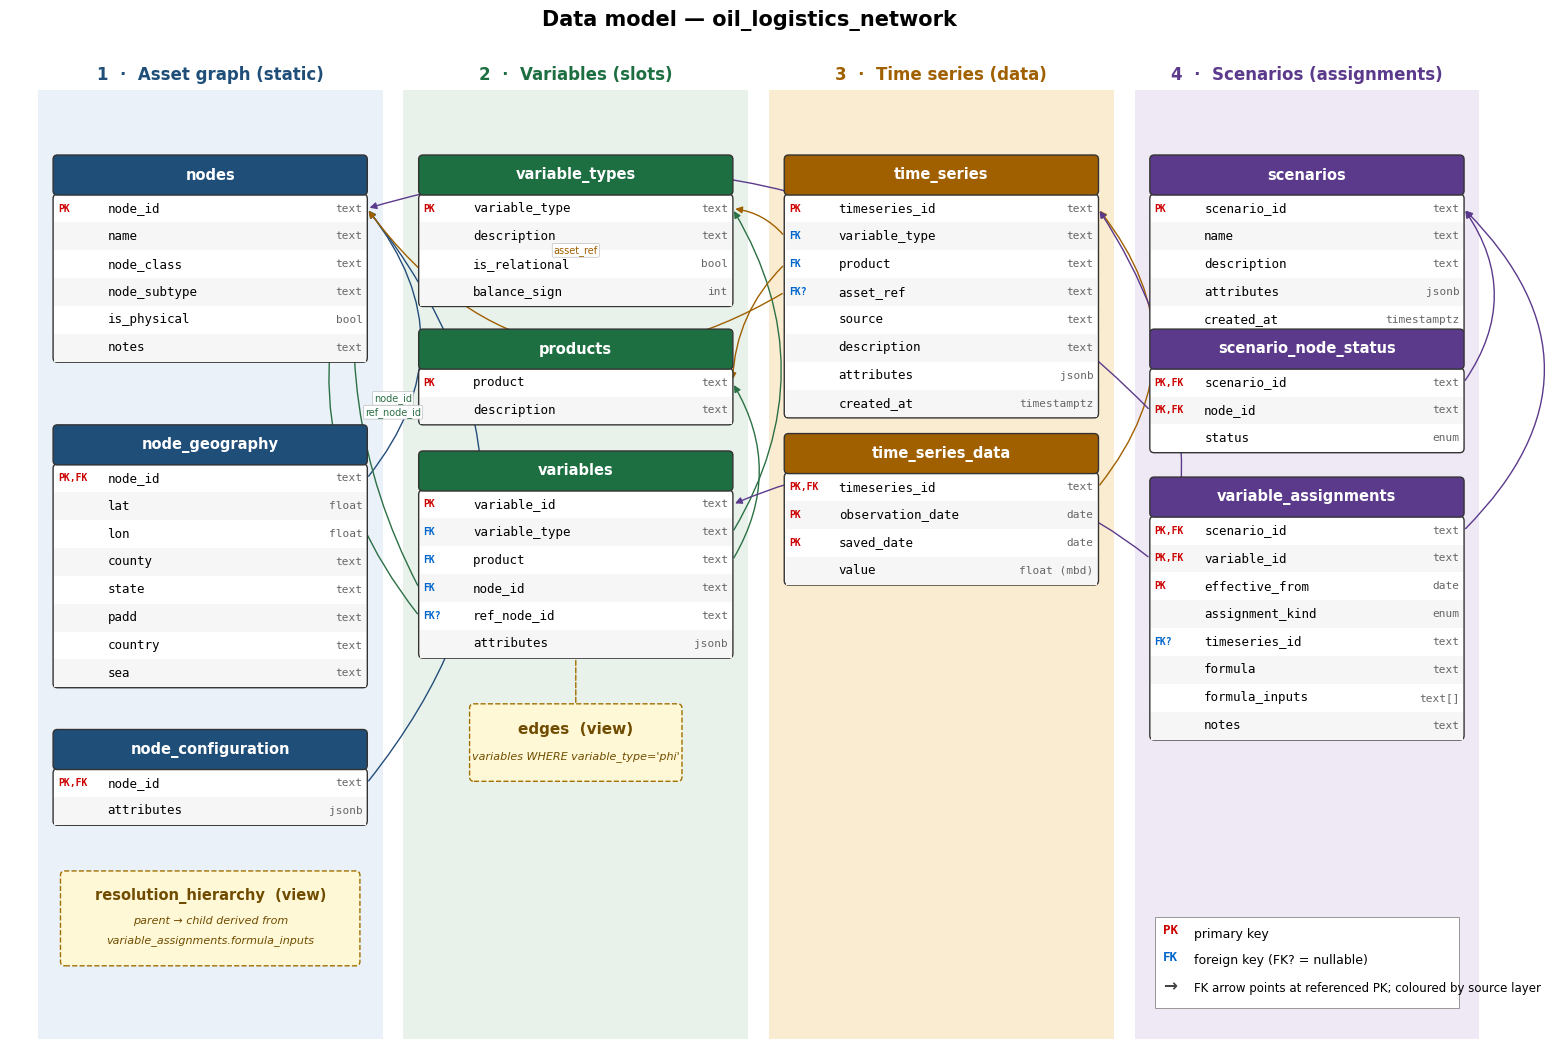

Saved: asset_graph\data_model.svg
Saved: asset_graph\data_model.png


In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

LAYER_HEAD = {1: "#1f4e79", 2: "#1d6f42", 3: "#a06000", 4: "#5b3a8c"}
LAYER_BG   = {1: "#eaf1f9", 2: "#e8f2eb", 3: "#faecd0", 4: "#efe9f5"}
LAYER_NAME = {
    1: "1  ·  Asset graph (static)",
    2: "2  ·  Variables (slots)",
    3: "3  ·  Time series (data)",
    4: "4  ·  Scenarios (assignments)",
}
FK_COLOR = {1: "#244e7a", 2: "#2c7045", 3: "#a06000", 4: "#5b3a8c"}

TABLE_W  = 3.6
HEADER_H = 0.45
ROW_H    = 0.32

T = {
    "nodes": (1, 0.3, 10.2, [
        ("PK", "node_id", "text"), ("", "name", "text"),
        ("", "node_class", "text"), ("", "node_subtype", "text"),
        ("", "is_physical", "bool"), ("", "notes", "text"),
    ]),
    "node_geography": (1, 0.3, 7.1, [
        ("PK,FK", "node_id", "text"),
        ("", "lat", "float"), ("", "lon", "float"),
        ("", "county", "text"), ("", "state", "text"),
        ("", "padd", "text"), ("", "country", "text"), ("", "sea", "text"),
    ]),
    "node_configuration": (1, 0.3, 3.6, [
        ("PK,FK", "node_id", "text"), ("", "attributes", "jsonb"),
    ]),
    "variable_types": (2, 4.5, 10.2, [
        ("PK", "variable_type", "text"), ("", "description", "text"),
        ("", "is_relational", "bool"), ("", "balance_sign", "int"),
    ]),
    "products": (2, 4.5, 8.2, [
        ("PK", "product", "text"), ("", "description", "text"),
    ]),
    "variables": (2, 4.5, 6.8, [
        ("PK", "variable_id", "text"),
        ("FK", "variable_type", "text"),
        ("FK", "product", "text"),
        ("FK", "node_id", "text"),
        ("FK?", "ref_node_id", "text"),
        ("", "attributes", "jsonb"),
    ]),
    "time_series": (3, 8.7, 10.2, [
        ("PK", "timeseries_id", "text"),
        ("FK", "variable_type", "text"),
        ("FK", "product", "text"),
        ("FK?", "asset_ref", "text"),
        ("", "source", "text"), ("", "description", "text"),
        ("", "attributes", "jsonb"), ("", "created_at", "timestamptz"),
    ]),
    "time_series_data": (3, 8.7, 7.0, [
        ("PK,FK", "timeseries_id", "text"),
        ("PK", "observation_date", "date"),
        ("PK", "saved_date", "date"),
        ("", "value", "float (mbd)"),
    ]),
    "scenarios": (4, 12.9, 10.2, [
        ("PK", "scenario_id", "text"), ("", "name", "text"),
        ("", "description", "text"),
        ("", "attributes", "jsonb"), ("", "created_at", "timestamptz"),
    ]),
    "scenario_node_status": (4, 12.9, 8.2, [
        ("PK,FK", "scenario_id", "text"),
        ("PK,FK", "node_id", "text"),
        ("", "status", "enum"),
    ]),
    "variable_assignments": (4, 12.9, 6.5, [
        ("PK,FK", "scenario_id", "text"),
        ("PK,FK", "variable_id", "text"),
        ("PK", "effective_from", "date"),
        ("", "assignment_kind", "enum"),
        ("FK?", "timeseries_id", "text"),
        ("", "formula", "text"),
        ("", "formula_inputs", "text[]"),
        ("", "notes", "text"),
    ]),
}

FKS = [
    ("node_geography",       "node_id",       "nodes",          "node_id",       "",  0.40),
    ("node_configuration",   "node_id",       "nodes",          "node_id",       "",  0.40),
    ("variables",            "variable_type", "variable_types", "variable_type", "",  0.30),
    ("variables",            "product",       "products",       "product",       "",  0.30),
    ("variables",            "node_id",       "nodes",          "node_id",       "node_id",     -0.18),
    ("variables",            "ref_node_id",   "nodes",          "node_id",       "ref_node_id", -0.30),
    ("time_series",          "variable_type", "variable_types", "variable_type", "",  0.20),
    ("time_series",          "product",       "products",       "product",       "",  0.20),
    ("time_series",          "asset_ref",     "nodes",          "node_id",       "asset_ref", -0.45),
    ("time_series_data",     "timeseries_id", "time_series",    "timeseries_id", "",  0.40),
    ("scenario_node_status", "scenario_id",   "scenarios",      "scenario_id",   "",  0.35),
    ("scenario_node_status", "node_id",       "nodes",          "node_id",       "",  0.30),
    ("variable_assignments", "scenario_id",   "scenarios",      "scenario_id",   "",  0.50),
    ("variable_assignments", "variable_id",   "variables",      "variable_id",   "",  0.30),
    ("variable_assignments", "timeseries_id", "time_series",    "timeseries_id", "",  0.25),
]

fig, ax = plt.subplots(figsize=(22, 13))
ax.set_xlim(-0.2, 16.8)
ax.set_ylim(-0.1, 11.4)
ax.set_aspect("equal"); ax.axis("off")

LAYER_BG_BOTTOM = 0.05
LAYER_BG_TOP = 10.95
for layer in (1, 2, 3, 4):
    xs = [(T[t][1], T[t][1] + TABLE_W) for t in T if T[t][0] == layer]
    x_min = min(p[0] for p in xs) - 0.18
    x_max = max(p[1] for p in xs) + 0.18
    ax.add_patch(Rectangle((x_min, LAYER_BG_BOTTOM), x_max - x_min,
                           LAYER_BG_TOP - LAYER_BG_BOTTOM,
                           facecolor=LAYER_BG[layer], edgecolor="none", zorder=0))
    ax.text((x_min + x_max) / 2, LAYER_BG_TOP + 0.18, LAYER_NAME[layer],
            ha="center", va="center", fontsize=12, fontweight="bold",
            color=LAYER_HEAD[layer])

anchors = {}
for tname, (layer, x, y_top, cols) in T.items():
    body_h  = ROW_H * len(cols)
    total_h = HEADER_H + body_h
    ax.add_patch(FancyBboxPatch((x, y_top - total_h), TABLE_W, body_h,
        boxstyle="round,pad=0.005,rounding_size=0.05",
        facecolor="white", edgecolor="#333", lw=1.0, zorder=2))
    ax.add_patch(FancyBboxPatch((x, y_top - HEADER_H), TABLE_W, HEADER_H,
        boxstyle="round,pad=0.005,rounding_size=0.05",
        facecolor=LAYER_HEAD[layer], edgecolor="#333", lw=1.0, zorder=2))
    ax.text(x + TABLE_W / 2, y_top - HEADER_H / 2, tname,
            ha="center", va="center", fontsize=10.5, fontweight="bold",
            color="white", zorder=3)
    cols_y = {}
    for i, (key, col_name, col_type) in enumerate(cols):
        cy = y_top - HEADER_H - (i + 0.5) * ROW_H
        if i % 2 == 1:
            ax.add_patch(Rectangle((x + 0.01, cy - ROW_H / 2),
                TABLE_W - 0.02, ROW_H,
                facecolor="#f6f6f6", edgecolor="none", zorder=2.4))
        if key:
            color = "#c00" if "PK" in key else "#06c"
            ax.text(x + 0.05, cy, key, ha="left", va="center",
                    fontsize=7, color=color, fontweight="bold",
                    fontfamily="monospace", zorder=3.5)
        ax.text(x + 0.62, cy, col_name, ha="left", va="center",
                fontsize=9, fontfamily="monospace", zorder=3.5)
        ax.text(x + TABLE_W - 0.05, cy, col_type, ha="right", va="center",
                fontsize=8, color="#666", fontfamily="monospace", zorder=3.5)
        cols_y[col_name] = cy
    anchors[tname] = {"cols": cols_y, "left": x, "right": x + TABLE_W,
                       "top": y_top, "bottom": y_top - total_h, "layer": layer}

for from_t, from_c, to_t, to_c, label, rad in FKS:
    f = anchors[from_t]; t = anchors[to_t]
    fy = f["cols"][from_c]; ty = t["cols"][to_c]
    color = FK_COLOR[f["layer"]]
    same_col = abs(f["left"] - t["left"]) < 0.5
    if same_col:
        x0, x1 = f["right"], t["right"]
        connstyle = f"arc3,rad={abs(rad)}"
    elif f["right"] < t["left"]:
        x0, x1 = f["right"], t["left"]
        connstyle = f"arc3,rad={rad}"
    else:
        x0, x1 = f["left"], t["right"]
        connstyle = f"arc3,rad={rad}"
    ax.annotate("", xy=(x1, ty), xytext=(x0, fy),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                connectionstyle=connstyle, lw=1.0,
                                shrinkA=2, shrinkB=2),
                zorder=1.6)
    if label:
        ax.text((x0 + x1) / 2, (fy + ty) / 2, label,
                fontsize=7, color=color, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15",
                          facecolor="white", edgecolor="#bbb",
                          lw=0.5, alpha=0.95), zorder=2.5)

# Two derived-view callouts.
v = anchors["variables"]
view_w, view_h = 2.4, 0.85
view_x = v["left"] + (TABLE_W - view_w) / 2
view_y = v["bottom"] - 0.55
ax.add_patch(FancyBboxPatch((view_x, view_y - view_h), view_w, view_h,
                            boxstyle="round,pad=0.02,rounding_size=0.05",
                            facecolor="#fff8d6", edgecolor="#a07000",
                            lw=1.0, linestyle="--", zorder=2))
ax.text(view_x + view_w/2, view_y - 0.27, "edges  (view)",
        ha="center", va="center", fontsize=11, fontweight="bold",
        color="#704c00", zorder=3)
ax.text(view_x + view_w/2, view_y - 0.58,
        "variables WHERE variable_type='phi'", ha="center", va="center",
        fontsize=8, color="#704c00", fontstyle="italic", zorder=3)
ax.annotate("", xy=(view_x + view_w/2, view_y),
            xytext=(v["left"] + TABLE_W/2, v["bottom"]),
            arrowprops=dict(arrowstyle="-", color="#a07000", lw=1.0,
                            linestyle="dashed"), zorder=1.8)

# resolution_hierarchy view callout in Layer 1's empty bottom area.
n = anchors["node_configuration"]
rh_w, rh_h = 3.4, 1.05
rh_x = n["left"] + (TABLE_W - rh_w) / 2
rh_y = n["bottom"] - 0.55
ax.add_patch(FancyBboxPatch((rh_x, rh_y - rh_h), rh_w, rh_h,
                            boxstyle="round,pad=0.02,rounding_size=0.05",
                            facecolor="#fff8d6", edgecolor="#a07000",
                            lw=1.0, linestyle="--", zorder=2))
ax.text(rh_x + rh_w/2, rh_y - 0.27, "resolution_hierarchy  (view)",
        ha="center", va="center", fontsize=10.5, fontweight="bold",
        color="#704c00", zorder=3)
ax.text(rh_x + rh_w/2, rh_y - 0.55,
        "parent → child derived from",
        ha="center", va="center",
        fontsize=8, color="#704c00", fontstyle="italic", zorder=3)
ax.text(rh_x + rh_w/2, rh_y - 0.78,
        "variable_assignments.formula_inputs",
        ha="center", va="center",
        fontsize=8, color="#704c00", fontstyle="italic", zorder=3)

ax.set_title("Data model — oil_logistics_network",
             fontsize=15, fontweight="bold", pad=18)

# Legend in Layer 4 bottom (empty area below variable_assignments)
lx, ly, lw, lh = 12.95, 0.4, 3.5, 1.05
ax.add_patch(Rectangle((lx, ly), lw, lh,
                       facecolor="white", edgecolor="#888", lw=0.6, zorder=2))
ax.text(lx + 0.10, ly + 0.85, "PK", color="#c00",
        fontweight="bold", fontfamily="monospace", fontsize=9, zorder=3)
ax.text(lx + 0.45, ly + 0.85, "primary key",
        fontsize=9, va="center", zorder=3)
ax.text(lx + 0.10, ly + 0.55, "FK", color="#06c",
        fontweight="bold", fontfamily="monospace", fontsize=9, zorder=3)
ax.text(lx + 0.45, ly + 0.55, "foreign key (FK? = nullable)",
        fontsize=9, va="center", zorder=3)
ax.text(lx + 0.10, ly + 0.20, "→", fontsize=12,
        fontweight="bold", color="#444", zorder=3)
ax.text(lx + 0.45, ly + 0.23,
        "FK arrow points at referenced PK; coloured by source layer",
        fontsize=8.5, va="center", zorder=3)

out_dir = Path("asset_graph"); out_dir.mkdir(exist_ok=True)
svg_path = out_dir / "data_model.svg"
png_path = out_dir / "data_model.png"
fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight", dpi=160)
plt.show()
print(f"Saved: {svg_path}")
print(f"Saved: {png_path}")